## Preprocessing the Image Data

#### The goal is to randomly exclude one sample from every unit to keep as our test dataset an then seperate the rest of the data into training and validation

In [166]:
# install dependencies
import numpy as np
import os
import random
import keras
from keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from pathlib import Path
import matplotlib.pyplot as plt

In [167]:
# test file paths for any file importing that needs to happen

file_path = Path("/Users/lucyhelms/MLGeo2026/samples.csv")

if file_path.exists() and file_path.is_file():
    print("File exists.")
else:
    print("File does not exist or is not a file.")

File exists.


In [168]:
# test directory paths for any folders that need opening
dir_path = Path("/Users/lucyhelms/MLGeo2026/non_fossil")

if dir_path.exists():
    print("Directory exists.")
else:
    print("Directory does not exist or cannot be found.")

Directory exists.


In [169]:
# list of all samples imaged in dataset
image_sample_list = pd.read_csv("/Users/lucyhelms/MLGeo2026/samples.csv")
print(image_sample_list.head)

# Want to make sure our test data has no overlap with training or validation
# So we are going to randomly pick one sample from each unit to omit

# OPB RANDOM SAMPLE

target_opb = "opb"
# filter the dataframe where the column contains the target string
filtered_opb = image_sample_list[image_sample_list['samples'].str.contains(target_opb)]
# randomly select one row
if not filtered_opb.empty:
    random_opb = filtered_df.sample(n=1).to_string(index=False, header=False) # Select 1 random row
    print(f"'{random_opb}'")
else:
    print(f"No rows found with '{target_opb}' in 'samples'")

# OPC RANDOM SAMPLE

target_opc = "opc"
filtered_opc = image_sample_list[image_sample_list['samples'].str.contains(target_opc)]

if not filtered_opc.empty:
    random_opc = filtered_opc.sample(n=1).to_string(index=False, header=False) # Select 1 random row
    print(f"Random sample with '{target_opc}':\n{random_opc}")
else:
    print(f"No rows found with '{target_opc}' in 'samples'")

# OPD RANDOM SAMPLE

target_opd = "opd"
filtered_opd = image_sample_list[image_sample_list['samples'].str.contains(target_opd)]

if not filtered_opd.empty:
    random_opd = filtered_opd.sample(n=1).to_string(index=False, header=False) # Select 1 random row
    print(f"Random sample with '{target_opd}':\n{random_opd}")
else:
    print(f"No rows found with '{target_opd}' in 'samples'")

# OPE RANDOM SAMPLE

target_ope = "ope"
filtered_ope = image_sample_list[image_sample_list['samples'].str.contains(target_ope)]

if not filtered_ope.empty:
    random_ope = filtered_ope.sample(n=1).to_string(index=False, header=False) # Select 1 random row
    print(f"Random sample with '{target_ope}':\n{random_ope}")
else:
    print(f"No rows found with '{target_ope}' in 'samples'")

# OPF RANDOM SAMPLE

target_opf = "opf"
filtered_opf = image_sample_list[image_sample_list['samples'].str.contains(target_opf)]

if not filtered_opf.empty:
    random_opf = filtered_opf.sample(n=1).to_string(index=False, header=False) # Select 1 random row
    print(f"Random sample with '{target_opf}':\n{random_opf}")
else:
    print(f"No rows found with '{target_opf}' in 'samples'")

<bound method NDFrame.head of      samples
0   opb_15.4
1   opb_19.2
2   opb_34.1
3   opb_41.6
4   opb_48.4
..       ...
78  opf_81.2
79  opf_85.0
80  opf_85.0
81  opf_93.0
82  opf_97.0

[83 rows x 1 columns]>
'opb_34.1'
Random sample with 'opc':
opc_18.0
Random sample with 'opd':
opd_59.0
Random sample with 'ope':
ope_37.5
Random sample with 'opf':
opf_77.0


i am 'resized_opf_61.0e_patch4.png'
i am 'resized_opf_14.0c_patch3.png'
i am 'resized_opf_11.2c_patch5.png'
i am 'resized_opf_37.0a_patch2.png'
i am 'resized_ope_26.0a_patch2.png'
i am 'resized_opb_19.2b_patch1.png'
i am 'resized_opd_80.0b_patch3.png'
i am 'resized_ope_78.0d_patch5.png'
i am 'resized_opf_41.0b_patch4.png'
i am 'resized_opd_64.0b_patch5.png'
i am 'resized_ope_26.0a_patch3.png'
i am 'resized_opf_11.2c_patch4.png'
i am 'resized_opf_29.0c_patch3.png'
i am 'resized_opf_61.0e_patch5.png'
i am 'resized_opc_45.6b_patch1.png'
i am 'resized_ope_82.0c_patch5.png'
i am 'resized_opc_39.6_patch4.png'
i am 'resized_opf_19.0a_patch1.png'
i am 'resized_ope_62.0c_patch2.png'
i am 'resized_opf_26.0b_patch4.png'
i am 'resized_opb_19.2b_patch3.png'
i am 'resized_opd_72.0d_patch3.png'
i am 'resized_opf_29.0c_patch4.png'
i am 'resized_opf_61.0e_patch2.png'
i am 'resized_opf_11.2c_patch3.png'
i am 'resized_opf_41.0b_patch3.png'
i am 'resized_opd_64.0b_patch2.png'
i am 'resized_ope_78.0d_patch

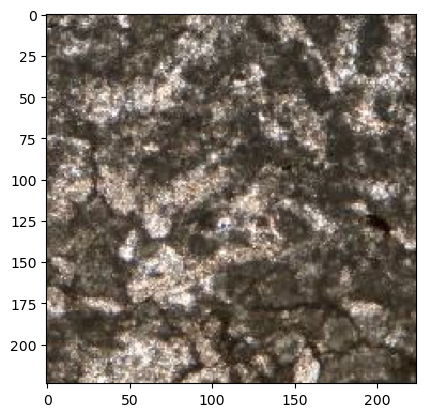

In [170]:
# assign variables to input folders of classified data
input_center_folder = "/Users/lucyhelms/MLGeo2026/center_fossil"
input_edge_folder = "/Users/lucyhelms/MLGeo2026/edge_fossil"
input_non_folder = "/Users/lucyhelms/MLGeo2026/non_fossil"

# make empty dataframe(?) for outputs to get sorted into
    
train_val = []
test = []

# identify random samples to omit in each folder
exclude_samples = random_opb or random_opc or random_opd or random_ope or random_opf


# FOSSIL IN THE CENTER FOLDER
# sort images containing random sample into test dataset
# all other images go into combined training and validation dataset

for file_name in os.listdir(input_center_folder):

    # ignore the random sample from each unit
    if exclude_samples in file_name:
       
       # join file name and directory into path
       full_path = os.path.join(input_center_folder, file_name)
       img = load_img(full_path, color_mode='rgb', target_size=(224, 224))
       plt.imshow(img)
       # add to list of test dataset images
       test.append(img)
       
    else:
       full_path = os.path.join(input_center_folder, file_name)
       img = load_img(full_path, color_mode='rgb', target_size=(224, 224))
       plt.imshow(img)
       # add to list of training and validation dataset images
       train_val.append(img)
       print(f"i am '{file_name}'")

# FOSSIL AROUND THE EDGE FOLDER

for file_name in os.listdir(input_edge_folder):

    # ignore the random sample from each unit
    if exclude_samples in file_name:
       
       # join file name and directory into path
       full_path = os.path.join(input_edge_folder, file_name)
       img = load_img(full_path, color_mode='rgb', target_size=(224, 224))
       plt.imshow(img)
       # add to list of test dataset images
       test.append(img)
       
    else:
       full_path = os.path.join(input_edge_folder, file_name)
       img = load_img(full_path, color_mode='rgb', target_size=(224, 224))
       plt.imshow(img)
       # add to list of training and validation dataset images
       train_val.append(img)
       print(f"i am '{file_name}'")

# NON FOSSIL FOLDER

for file_name in os.listdir(input_non_folder):

    # ignore the random sample from each unit
    if exclude_samples in file_name:
       
       # join file name and directory into path
       full_path = os.path.join(input_non_folder, file_name)
       img = load_img(full_path, color_mode='rgb', target_size=(224, 224))
       plt.imshow(img)
       # add to list of test dataset images
       test.append(img)
       
    else:
       full_path = os.path.join(input_non_folder, file_name)
       img = load_img(full_path, color_mode='rgb', target_size=(224, 224))
       plt.imshow(img)
       # add to list of training and validation dataset images
       train_val.append(img)
       print(f"i am '{file_name}'")


print(f"Training + Validation: {len(train_val)} elements")
print(f"Testing: {len(test)} elements")

In [171]:
# split into training and validation set

training_dataset = []
validation_dataset = []

random.shuffle(train_val)
split_index = int(len(train_val) * 0.8)
training_dataset = train_val[:split_index]
validation_dataset = train_val[split_index:]

print(f"Training (80%): {len(training_dataset)} elements")
print(f"Validation (20%): {len(validation_dataset)} elements")
print(f"Testing: {len(test)} elements")

Training (80%): 692 elements
Validation (20%): 174 elements
Testing: 0 elements
